In [239]:
# Teste de Conhecimento 1

## Modelo de regressão para estimar o valor de empréstimo para um cliente.

## Este notebook utiliza os dados fornecidos para construir um modelo de regressão capaz de estimar o valor de empréstimo que pode ser oferecido a um novo cliente.

In [240]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [241]:
## Etapa 1 – Carregar os Dados

dados = pd.read_csv("base_credito.csv")

dados

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


In [242]:
## Etapa 2 – Conhecer os Dados

### a) Quais são as variáveis utilizadas como entrada;
# As variáveis de entrada são:
# idade
# renda_mensal
# score_credito
# historico_pagamentos
# Essas variáveis representam características dos clientes utilizadas pelo modelo para estimar o valor do empréstimo.

### b) Qual é a variável dependente?
# A variável dependente é "valor_emprestimo", pois é o valor que queremos que o modelo aprenda a prever.

### c) Quais tipos de dados estão presentes na base.
# A base é composta por dados numéricos. A variável idade e o score_credito são valores inteiros, enquanto renda_mensal, historico_pagamentos e valor_emprestimo são valores decimais.
# Esses dados podem ser utilizados diretamente em um modelo de regressão, pois representam características quantitativas dos clientes.

### Explique brevemente o significado de cada variável.
# idade -	idade do cliente
# renda_mensal -	renda mensal do cliente, em reais
# score_credito -	pontuação de crédito do cliente
# historico_pagamentos -	indicador relacionado ao histórico de pagamentos
# valor_emprestimo -	valor do empréstimo aprovado, em reais

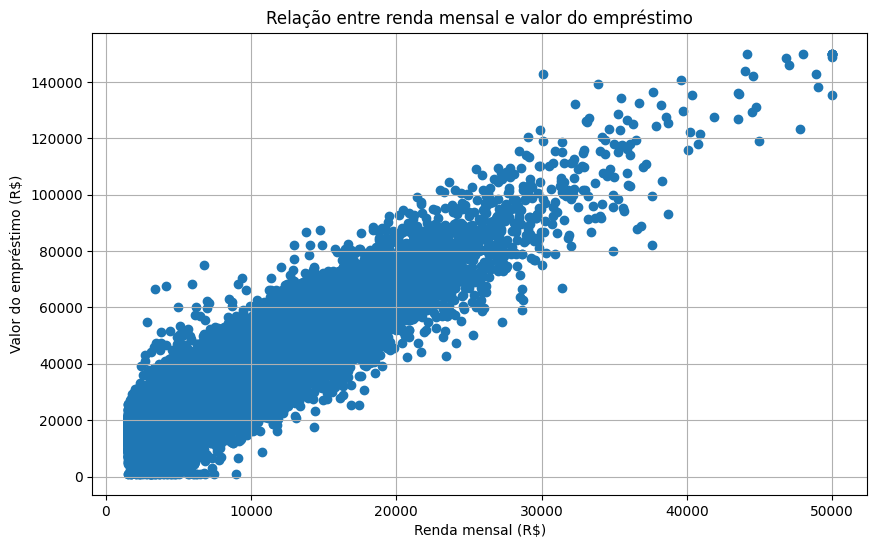

In [243]:
## Etapa 3 – Analisar os Dados

plt.figure(figsize=(10, 6))

plt.scatter(
    dados["renda_mensal"],
    dados["valor_emprestimo"]
)

plt.title("Relação entre renda mensal e valor do empréstimo")
plt.xlabel("Renda mensal (R$)")
plt.ylabel("Valor do empréstimo (R$)")

plt.grid(True)

plt.show()

In [244]:
### Análise do gráfico

# Observa-se uma tendência de aumento no valor do empréstimo conforme a renda mensal aumenta. Isso indica que existe uma relação positiva entre essas duas variáveis.
# Entretanto, os pontos não estão exatamente sobre uma mesma linha, mostrando que outros fatores, como idade, score de crédito e histórico de pagamentos, também podem influenciar o valor do empréstimo.

In [245]:
## Etapa 4 – Preparar os Dados

X = dados[
    [
        "idade",
        "renda_mensal",
        "score_credito",
        "historico_pagamentos"
    ]
]

y = dados["valor_emprestimo"]

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Total de registros: {len(dados)}")
print(f"Treinamento: {len(X_treino)} registros ({len(X_treino)/len(dados)*100:.0f}%)")
print(f"Teste: {len(X_teste)} registros ({len(X_teste)/len(dados)*100:.0f}%)")

Total de registros: 50000
Treinamento: 40000 registros (80%)
Teste: 10000 registros (20%)


In [246]:
### Etapa 5 – Treinar o Modelo

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

In [247]:
### Etapa 6 – Avaliar o Modelo

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print(f"MAE: R$ {mae:.2f}")
print(f"R²: {r2:.4f}")

MAE: R$ 2985.94
R²: 0.9223


In [248]:
### Análise das métricas

# O modelo apresentou um MAE de R$ 2.985,94, indicando que, em média, os valores previstos pelo modelo ficaram aproximadamente R$ 2.985,94 distantes dos valores reais dos empréstimos.
# O R² foi de 0,9223, indicando que o modelo conseguiu explicar aproximadamente 92,23% da variação dos valores dos empréstimos presentes nos dados de teste.
# Esse resultado mostra que as variáveis utilizadas no modelo possuem relação com o valor do empréstimo dentro desta base.
# Portanto, as métricas indicam que o modelo conseguiu representar uma parcela considerável da variação existente nos valores dos empréstimos, embora ainda apresente erros nas previsões.

In [249]:
### Etapa 7 – Comparar valores reais e previstos

comparacao = pd.DataFrame({
    "Valor real": y_teste.values,
    "Valor previsto": previsoes
})

comparacao["Valor real"] = comparacao["Valor real"].map(
    lambda valor: f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

comparacao["Valor previsto"] = comparacao["Valor previsto"].map(
    lambda valor: f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

comparacao.head(10)

,Valor real,Valor previsto
0,"R$ 22.268,46","R$ 14.806,34"
1,"R$ 27.457,59","R$ 29.512,49"
2,"R$ 25.451,04","R$ 25.840,74"
3,"R$ 23.890,67","R$ 21.077,52"
4,"R$ 27.754,95","R$ 27.919,31"
5,"R$ 12.544,92","R$ 14.530,91"
6,"R$ 28.759,01","R$ 27.385,97"
7,"R$ 46.454,49","R$ 41.011,61"
8,"R$ 43.199,01","R$ 36.525,09"
9,"R$ 34.051,39","R$ 35.786,96"


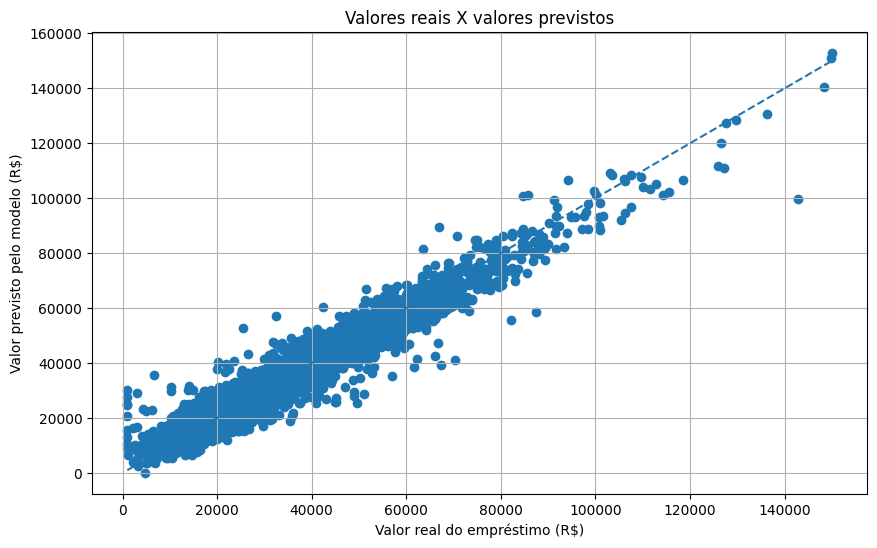

In [250]:
### Gráfico da comparação

plt.figure(figsize=(10, 6))

plt.scatter(y_teste, previsoes)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    linestyle="--"
)

plt.xlabel("Valor real do empréstimo (R$)")
plt.ylabel("Valor previsto pelo modelo (R$)")
plt.title("Valores reais X valores previstos")

plt.grid(True)

plt.show()

In [251]:
### Etapa 8 – Fazer uma previsão

novo_cliente = pd.DataFrame({
    "idade": [35],
    "renda_mensal": [8000],
    "score_credito": [700],
    "historico_pagamentos": [90]
})

previsao_novo_cliente = modelo.predict(novo_cliente)

print(
    f"Valor previsto do empréstimo: R$ {previsao_novo_cliente[0]:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

Valor previsto do empréstimo: R$ 36.627,66


In [252]:
### Interpretação do resultado
# Para testar o modelo com um novo cliente, foram informadas características que não pertenciam ao conjunto de dados utilizado no teste.
# O cliente possui 35 anos, renda mensal de R$ 8.000,00, score de crédito de 700 e histórico de pagamentos de 90%.
# Com essas características, o modelo estimou um valor de empréstimo de R$ 36.627,66.
# Essa previsão representa uma estimativa gerada pelo modelo de regressão a partir das relações identificadas nos dados de treinamento.

In [253]:
### Etapa 9 – Conclusão

# O objetivo deste trabalho foi desenvolver um modelo de regressão capaz de estimar o valor de empréstimo para novos clientes de uma fintech.
# Para isso, foram utilizadas as variáveis idade, renda mensal, score de crédito e histórico de pagamentos como características de entrada, tendo como variável de saída o valor do empréstimo.
#  A base foi dividida em 80% para treinamento, totalizando 40.000 registros, e 20% para teste, totalizando 10.000 registros. Após o treinamento do modelo, foram utilizadas as métricas MAE e R² para avaliar seu desempenho.
# O modelo apresentou MAE de R$ 2.985,94, indicando que, em média, suas previsões apresentaram uma diferença de aproximadamente R$ 2.985,94 em relação aos valores reais.
# O R² de 0,9223 indica que o modelo conseguiu explicar aproximadamente 92,23% da variação dos valores de empréstimo presentes no conjunto de teste.
# Também foi realizada uma previsão para um novo cliente, com 35 anos, renda mensal de R$ 8.000,00, score de crédito de 700 e histórico de pagamentos de 90%. Para esse cliente, o modelo estimou um valor de empréstimo de R$ 36.627,66.
# Os resultados mostram que a regressão pode ser utilizada para realizar estimativas de valores de empréstimos a partir das características disponíveis na base.
# Entretanto, o modelo possui limitações, pois suas previsões não são exatas e podem apresentar diferenças em relação aos valores reais.
# Além disso, outras características que não estão presentes na base podem influenciar a decisão de crédito. Portanto, a previsão deve ser considerada uma estimativa, e não uma decisão definitiva sobre a concessão do empréstimo.